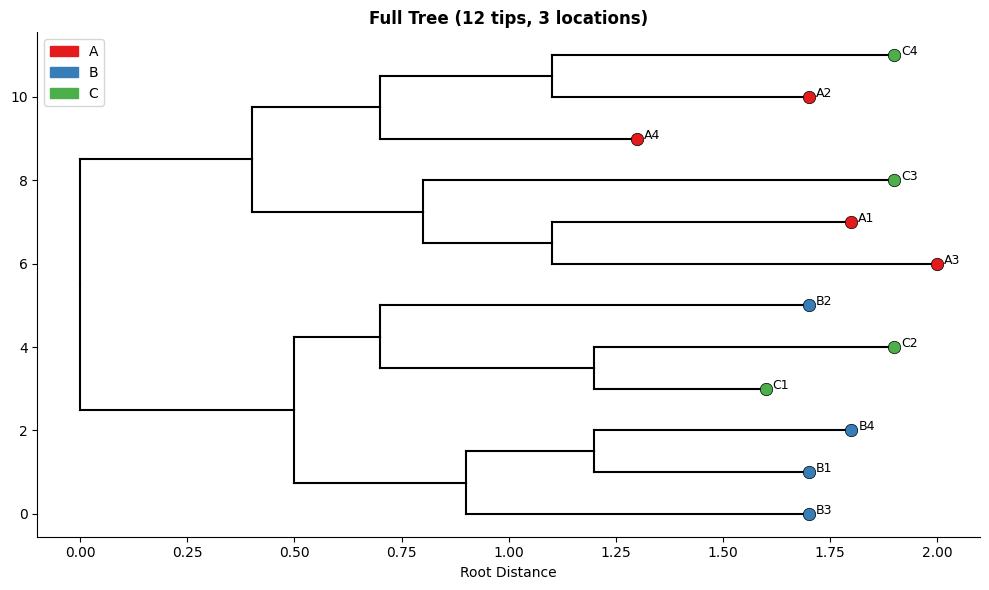

In [57]:
# Cell 1: Load and Plot Example Tree

import dendropy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Define tree with 12 tips (4 per location A, B, C) - serial sampling
# Swapped: B4<->A2, B3<->A1
newick = """
(
  ((B3:0.8, (B1:0.5, B4:0.6):0.3):0.4, ((C1:0.4, C2:0.7):0.5, B2:1.0):0.2):0.5,
  (((A3:0.9, A1:0.7):0.3, C3:1.1):0.4, (A4:0.6, (A2:0.6, C4:0.8):0.4):0.3):0.4
):0.0;
"""

tree = dendropy.Tree.get(data=newick, schema="newick")
for tip in tree.leaf_node_iter():
    tip.location = tip.taxon.label[0]
tree.calc_node_root_distances()

# Compute y positions
def compute_y_positions(tree):
    y_pos, leaf_count = {}, [0]
    def assign_y(node):
        if node.is_leaf():
            y_pos[id(node)] = leaf_count[0]
            leaf_count[0] += 1
        else:
            for c in node.child_nodes(): assign_y(c)
            y_pos[id(node)] = np.mean([y_pos[id(c)] for c in node.child_nodes()])
    assign_y(tree.seed_node)
    return y_pos

# Plot full tree
fig, ax = plt.subplots(figsize=(10, 6))
y_pos = compute_y_positions(tree)
colors = {'A': '#e41a1c', 'B': '#377eb8', 'C': '#4daf4a'}

for node in tree.preorder_node_iter():
    if node.parent_node:
        x1, x2 = node.parent_node.root_distance, node.root_distance
        y1, y2 = y_pos[id(node.parent_node)], y_pos[id(node)]
        ax.plot([x1, x1], [y1, y2], color='black', lw=1.5)
        ax.plot([x1, x2], [y2, y2], color='black', lw=1.5)

for node in tree.leaf_node_iter():
    x, y = node.root_distance, y_pos[id(node)]
    ax.scatter(x, y, c=colors[node.location], s=80, edgecolors='black', linewidths=0.5, zorder=5)
    ax.annotate(node.taxon.label, (x, y), xytext=(5, 0), textcoords='offset points', fontsize=9)

ax.set_title('Full Tree (12 tips, 3 locations)', fontweight='bold')
ax.set_xlabel('Root Distance')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(handles=[mpatches.Patch(color=c, label=l) for l, c in colors.items()], loc='upper left')
plt.tight_layout()
plt.show()

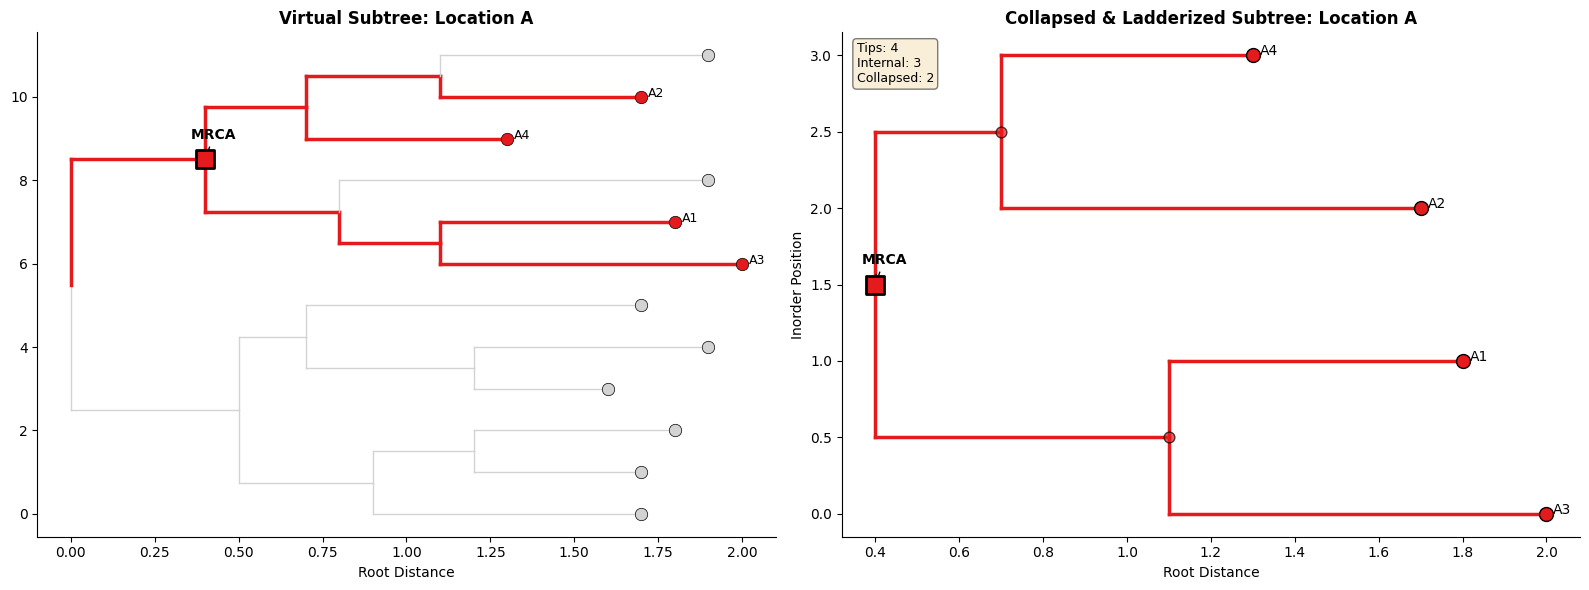

Tips: ['A3', 'A1', 'A2', 'A4']
Check: 4 tips -> 3 internal expected, got 3


In [58]:
# Cell 2: Virtual Subtree vs Collapsed & Ladderized (Side-by-Side)

# Preprocess: compute loc_counts and loc_max_dist for each node
for node in tree.postorder_node_iter():
    if node.is_leaf():
        loc = node.location
        node.loc_counts = {loc: 1}
        node.loc_max_dist = {loc: node.root_distance}
    else:
        node.loc_counts, node.loc_max_dist = {}, {}
        for child in node.child_nodes():
            for loc, cnt in child.loc_counts.items():
                node.loc_counts[loc] = node.loc_counts.get(loc, 0) + cnt
            for loc, dist in child.loc_max_dist.items():
                node.loc_max_dist[loc] = max(node.loc_max_dist.get(loc, 0), dist)

# Find MRCA for target location
def find_mrca(tree, target_loc):
    root = tree.seed_node
    total = root.loc_counts.get(target_loc, 0)
    if total < 2:
        return None
    mrca = root
    while True:
        children_with_all = [c for c in mrca.child_nodes() if c.loc_counts.get(target_loc, 0) == total]
        if len(children_with_all) == 1:
            mrca = children_with_all[0]
        else:
            break
    return mrca

# CBLV Encoder
class VirtualSubtreeEncoder:
    def __init__(self, tree, tree_height):
        self.tree = tree
        self.tree_height = tree_height

    def _find_mrca(self, target_loc):
        total = self.tree.seed_node.loc_counts.get(target_loc, 0)
        if total < 2:
            return None
        mrca = self.tree.seed_node
        while True:
            children_with_all = [c for c in mrca.child_nodes() if c.loc_counts.get(target_loc, 0) == total]
            if len(children_with_all) == 1:
                mrca = children_with_all[0]
            else:
                break
        return mrca

    def _is_branching_point(self, node, target_loc):
        if node.is_leaf():
            return False
        return sum(1 for c in node.child_nodes() if c.loc_counts.get(target_loc, 0) > 0) >= 2

    def _find_parent_branching_point(self, node, target_loc, mrca):
        current = node.parent_node
        while current:
            if current == mrca or self._is_branching_point(current, target_loc):
                return current
            current = current.parent_node
        return mrca

    def _compute_accumulated_edge(self, node, parent_branch):
        total = 0
        current = node
        while current != parent_branch and current:
            total += current.edge_length or 0
            current = current.parent_node
        return total

    def _virtual_inorder(self, node, target_loc, last_branch_dist, mrca, trace):
        if node.is_leaf():
            if node.location == target_loc:
                parent_branch = self._find_parent_branching_point(node, target_loc, mrca)
                accum = self._compute_accumulated_edge(node, parent_branch)
                height = node.root_distance - last_branch_dist
                trace.append(('leaf', node, height, accum))
                yield ('leaf', height, accum, node)
        elif self._is_branching_point(node, target_loc):
            # LADDERIZE: sort by loc_max_dist descending
            children = sorted(
                [c for c in node.child_nodes() if c.loc_counts.get(target_loc, 0) > 0],
                key=lambda c: c.loc_max_dist.get(target_loc, 0), reverse=True
            )
            yield from self._virtual_inorder(children[0], target_loc, last_branch_dist, mrca, trace)
            accum = node.edge_length or 0 if node == mrca else self._compute_accumulated_edge(
                node, self._find_parent_branching_point(node, target_loc, mrca))
            trace.append(('internal', node, node.root_distance, accum))
            yield ('internal', node.root_distance, accum, node)
            for child in children[1:]:
                yield from self._virtual_inorder(child, target_loc, node.root_distance, mrca, trace)
        else:
            # COLLAPSE: only 1 relevant child
            relevant = [c for c in node.child_nodes() if c.loc_counts.get(target_loc, 0) > 0]
            if relevant:
                trace.append(('collapse', node, None, None))
                yield from self._virtual_inorder(relevant[0], target_loc, last_branch_dist, mrca, trace)

    def encode_cblv(self, target_loc, rescale=True):
        mrca = self._find_mrca(target_loc)
        if mrca is None:
            return np.zeros((1, 4)), [], None
        n_tips = mrca.loc_counts.get(target_loc, 0)
        stem = mrca.root_distance
        heights = np.zeros((n_tips, 4))
        trace = []
        idx = 0
        for event in self._virtual_inorder(mrca, target_loc, mrca.root_distance, mrca, trace):
            if idx >= n_tips:
                break
            if event[0] == 'leaf':
                heights[idx, 0] = event[1] + (stem if idx == 0 else 0)
                heights[idx, 2] = event[2]
            else:
                if idx + 1 < n_tips:
                    heights[idx + 1, 1] = event[1]
                    heights[idx + 1, 3] = event[2]
                idx += 1
        if rescale:
            heights /= self.tree_height
        return heights, trace, mrca

# Create encoder and encode
tree_height = max(t.root_distance for t in tree.leaf_node_iter())
encoder = VirtualSubtreeEncoder(tree, tree_height)
target_loc = 'A'
cblv, trace, mrca = encoder.encode_cblv(target_loc)

# Extract nodes from trace
leaf_nodes = [item[1] for item in trace if item[0] == 'leaf']
internal_events = [item for item in trace if item[0] == 'internal']
collapsed_nodes = [item[1] for item in trace if item[0] == 'collapse']

# Virtual y positions for collapsed/ladderized tree
virtual_y = {}
for i, node in enumerate(leaf_nodes):
    virtual_y[id(node)] = i

def get_virtual_children(node, target_loc):
    if node.is_leaf():
        return []
    if not encoder._is_branching_point(node, target_loc):
        relevant = [c for c in node.child_nodes() if c.loc_counts.get(target_loc, 0) > 0]
        return get_virtual_children(relevant[0], target_loc) if relevant else []
    children = sorted(
        [c for c in node.child_nodes() if c.loc_counts.get(target_loc, 0) > 0],
        key=lambda c: c.loc_max_dist.get(target_loc, 0), reverse=True
    )
    result = []
    for c in children:
        if c.is_leaf() and c.location == target_loc:
            result.append(c)
        elif encoder._is_branching_point(c, target_loc):
            result.append(c)
        else:
            curr = c
            while curr and not curr.is_leaf() and not encoder._is_branching_point(curr, target_loc):
                relevant = [x for x in curr.child_nodes() if x.loc_counts.get(target_loc, 0) > 0]
                curr = relevant[0] if relevant else None
            if curr:
                result.append(curr)
    return result

def compute_virtual_y(node, target_loc):
    if node.is_leaf():
        return virtual_y.get(id(node), 0)
    children = get_virtual_children(node, target_loc)
    if children:
        y = np.mean([compute_virtual_y(c, target_loc) for c in children])
        virtual_y[id(node)] = y
        return y
    return 0

compute_virtual_y(mrca, target_loc)

# ========== SIDE-BY-SIDE PLOT ==========
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ----- LEFT: Virtual Subtree (highlighting on full tree) -----
for node in tree.preorder_node_iter():
    if node.parent_node:
        x1, x2 = node.parent_node.root_distance, node.root_distance
        y1, y2 = y_pos[id(node.parent_node)], y_pos[id(node)]
        in_subtree = node.loc_counts.get(target_loc, 0) > 0
        color = colors[target_loc] if in_subtree else 'lightgray'
        lw = 2.5 if in_subtree else 1
        ax1.plot([x1, x1], [y1, y2], color=color, lw=lw)
        ax1.plot([x1, x2], [y2, y2], color=color, lw=lw)

for node in tree.leaf_node_iter():
    x, y = node.root_distance, y_pos[id(node)]
    c = colors[target_loc] if node.location == target_loc else 'lightgray'
    ax1.scatter(x, y, c=c, s=80, edgecolors='black', linewidths=0.5, zorder=5)
    if node.location == target_loc:
        ax1.annotate(node.taxon.label, (x, y), xytext=(5, 0), textcoords='offset points', fontsize=9)

# Highlight MRCA
if mrca:
    ax1.scatter(mrca.root_distance, y_pos[id(mrca)], marker='s', s=150, 
               c=colors[target_loc], edgecolors='black', linewidths=2, zorder=10)
    ax1.annotate('MRCA', (mrca.root_distance, y_pos[id(mrca)]), 
                xytext=(-10, 15), textcoords='offset points', fontsize=10, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='black'))

ax1.set_title(f'Virtual Subtree: Location {target_loc}', fontweight='bold')
ax1.set_xlabel('Root Distance')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ----- RIGHT: Collapsed & Ladderized Subtree -----
def draw_virtual_edges(node, target_loc, parent_x=None, parent_y=None):
    x, y = node.root_distance, virtual_y.get(id(node), 0)
    if parent_x is not None:
        ax2.plot([parent_x, parent_x], [parent_y, y], color=colors[target_loc], lw=2.5)
        ax2.plot([parent_x, x], [y, y], color=colors[target_loc], lw=2.5)
    if not node.is_leaf():
        for c in get_virtual_children(node, target_loc):
            draw_virtual_edges(c, target_loc, x, y)

draw_virtual_edges(mrca, target_loc)

for node in leaf_nodes:
    x, y = node.root_distance, virtual_y[id(node)]
    ax2.scatter(x, y, c=colors[target_loc], s=100, edgecolors='black', linewidths=1, zorder=5)
    ax2.annotate(node.taxon.label, (x, y), xytext=(5, 0), textcoords='offset points', fontsize=10)

for item in internal_events:
    node = item[1]
    ax2.scatter(node.root_distance, virtual_y[id(node)], c=colors[target_loc], s=60, marker='o',
               edgecolors='black', linewidths=1, zorder=5, alpha=0.7)

ax2.scatter(mrca.root_distance, virtual_y[id(mrca)], marker='s', s=150,
           c=colors[target_loc], edgecolors='black', linewidths=2, zorder=10)
ax2.annotate('MRCA', (mrca.root_distance, virtual_y[id(mrca)]),
            xytext=(-10, 15), textcoords='offset points', fontsize=10, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='black'))

ax2.set_title(f'Collapsed & Ladderized Subtree: Location {target_loc}', fontweight='bold')
ax2.set_xlabel('Root Distance')
ax2.set_ylabel('Inorder Position')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.text(0.02, 0.98, f"Tips: {len(leaf_nodes)}\nInternal: {len(internal_events)}\nCollapsed: {len(collapsed_nodes)}",
        transform=ax2.transAxes, fontsize=9, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"Tips: {[n.taxon.label for n in leaf_nodes]}")
print(f"Check: {len(leaf_nodes)} tips -> {len(leaf_nodes)-1} internal expected, got {len(internal_events)}")

In [59]:
# Cell 3: CBLV Matrix Output

# Get both unnormalized and normalized CBLV
cblv_raw, _, _ = encoder.encode_cblv(target_loc, rescale=False)
cblv_norm, _, _ = encoder.encode_cblv(target_loc, rescale=True)

print(f"CBLV for location {target_loc}:")
print(f"  Shape: {cblv_norm.shape} ({cblv_norm.shape[0]} tips x 4 columns)")
print(f"  MRCA root_distance: {mrca.root_distance:.4f}")
print(f"  Tree height: {tree_height:.4f}")

print(f"\nTraversal trace:")
for item in trace:
    if item[0] == 'leaf':
        print(f"  LEAF: {item[1].taxon.label}")
    elif item[0] == 'internal':
        print(f"  INTERNAL (branching point)")
    else:
        print(f"  [COLLAPSED]")

tip_names = [item[1].taxon.label for item in trace if item[0] == 'leaf']

print(f"\n{'='*60}")
print(f"CBLV Matrix (BEFORE normalization):")
print(f"{'='*60}")
print(f"{'Tip':<8} {'col0':>8} {'col1':>8} {'col2':>8} {'col3':>8}")
for i, row in enumerate(cblv_raw):
    print(f"{tip_names[i]:<8} {row[0]:>8.4f} {row[1]:>8.4f} {row[2]:>8.4f} {row[3]:>8.4f}")

print(f"\n{'='*60}")
print(f"CBLV Matrix (AFTER normalization, divided by tree_height={tree_height:.4f}):")
print(f"{'='*60}")
print(f"{'Tip':<8} {'col0':>8} {'col1':>8} {'col2':>8} {'col3':>8}")
for i, row in enumerate(cblv_norm):
    print(f"{tip_names[i]:<8} {row[0]:>8.4f} {row[1]:>8.4f} {row[2]:>8.4f} {row[3]:>8.4f}")

CBLV for location A:
  Shape: (4, 4) (4 tips x 4 columns)
  MRCA root_distance: 0.4000
  Tree height: 2.0000

Traversal trace:
  [COLLAPSED]
  LEAF: A3
  INTERNAL (branching point)
  LEAF: A1
  INTERNAL (branching point)
  [COLLAPSED]
  LEAF: A2
  INTERNAL (branching point)
  LEAF: A4

CBLV Matrix (BEFORE normalization):
Tip          col0     col1     col2     col3
A3         2.0000   0.0000   0.9000   0.0000
A1         0.7000   1.1000   0.7000   0.7000
A2         1.3000   0.4000   1.0000   0.4000
A4         0.6000   0.7000   0.6000   0.3000

CBLV Matrix (AFTER normalization, divided by tree_height=2.0000):
Tip          col0     col1     col2     col3
A3         1.0000   0.0000   0.4500   0.0000
A1         0.3500   0.5500   0.3500   0.3500
A2         0.6500   0.2000   0.5000   0.2000
A4         0.3000   0.3500   0.3000   0.1500
